In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal, interpolate
from itertools import product
import importlib

import plot_helpers
importlib.reload(plot_helpers)
from plot_helpers import (
    setup_plotting_style,
    style_ax,
    get_step_formatter,
    save_figure,
    COLOR_NGRAM,
    COLOR_PCFG,
    PAPER_WIDTH_IN,
    PAPER_HEIGHT_IN,
)

import data_loader
importlib.reload(data_loader)
from data_loader import (
    load_wandb_training_data,
    load_and_print_olmo_data,
    load_and_print_ngram_data,
    load_and_print_pcfg_data,
)


setup_plotting_style(style="paper")

import warnings
warnings.filterwarnings('ignore')

olmo_df = load_and_print_olmo_data()
ngram_df = load_and_print_ngram_data()
pcfg_df = load_and_print_pcfg_data()

Loading W&B data from 32 runs...

allenai/OLMo-1B-hf training data:
  Steps: 7 - 381445
  Data points: 15681
  Loss range: 2.4040 - 10.4210

First few rows:
      step       loss
2000     7  10.421010
1        8  10.198186
1002    11   9.164018
3003    12   9.153295
3004    14   8.868561
N-gram language experiment data:
  Steps: 503 - 46779
  Data points: 93
  Loss range: 1.7615 - 2.0794

First few rows:
   step    loss  learning_rate     epoch
0   503  2.0794       0.000050  0.002643
1  1006  1.7676       0.000049  0.005285
2  1509  1.7657       0.000049  0.007928
3  2012  1.7650       0.000048  0.010570
4  2515  1.7644       0.000048  0.013213
PCFG language experiment data:
  Steps: 386 - 38214
  Data points: 99
  Loss range: 4.6308 - 5.4150

First few rows:
   step    loss  learning_rate     epoch
0   386  5.4150       0.000050  0.010003
1   772  4.9257       0.000049  0.020006
2  1158  4.9085       0.000049  0.030009
3  1544  4.9037       0.000048  0.040011
4  1930  4.9153       0.

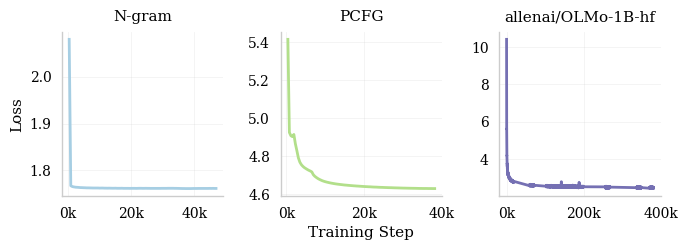

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(PAPER_WIDTH_IN, PAPER_HEIGHT_IN * 0.6))

def set_black_labels(ax):
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

axes[0].plot(ngram_df['step'], ngram_df['loss'], linewidth=2.0, color=COLOR_NGRAM)
style_ax(axes[0], style="paper")
axes[0].set_title('N-gram', fontsize=11, pad=8, color='black')
axes[0].xaxis.set_major_formatter(get_step_formatter())
set_black_labels(axes[0])

axes[1].plot(pcfg_df['step'], pcfg_df['loss'], linewidth=2.0, color=COLOR_PCFG)
style_ax(axes[1], style="paper")
axes[1].set_title('PCFG', fontsize=11, pad=8, color='black')
axes[1].xaxis.set_major_formatter(get_step_formatter())
set_black_labels(axes[1])

axes[2].plot(olmo_df['step'], olmo_df['loss'], linewidth=2.0, color='#7570b3')
style_ax(axes[2], style="paper")
axes[2].set_title('allenai/OLMo-1B-hf', fontsize=11, pad=8, color='black')
axes[2].xaxis.set_major_formatter(get_step_formatter())
set_black_labels(axes[2])

axes[0].set_ylabel("Loss", color='black')
axes[1].set_ylabel(None)
axes[2].set_ylabel(None)

axes[0].set_xlabel(None)
axes[1].set_xlabel("Training Step", color='black')
axes[2].set_xlabel(None)

plt.tight_layout()
save_figure(fig, "raw_loss_curves.svg")
plt.show()